In [1]:
#import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib


In [2]:
df = pd.read_csv("dynamic_pricing.csv")
df

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422
...,...,...,...,...,...,...,...,...,...,...
995,33,23,Urban,Gold,24,4.21,Morning,Premium,11,91.389526
996,84,29,Urban,Regular,92,4.55,Morning,Premium,94,424.155987
997,44,6,Suburban,Gold,80,4.13,Night,Premium,40,157.364830
998,53,27,Suburban,Regular,78,3.63,Night,Premium,58,279.095048


In [3]:
# Display first 5 rows
print(df.head())

   Number_of_Riders  Number_of_Drivers Location_Category  \
0                90                 45             Urban   
1                58                 39          Suburban   
2                42                 31             Rural   
3                89                 28             Rural   
4                78                 22             Rural   

  Customer_Loyalty_Status  Number_of_Past_Rides  Average_Ratings  \
0                  Silver                    13             4.47   
1                  Silver                    72             4.06   
2                  Silver                     0             3.99   
3                 Regular                    67             4.31   
4                 Regular                    74             3.77   

  Time_of_Booking Vehicle_Type  Expected_Ride_Duration  \
0           Night      Premium                      90   
1         Evening      Economy                      43   
2       Afternoon      Premium                      76  

In [ ]:

print("\nDataset Shape:")
print(df.shape)

In [ ]:

print("\nDataset Info:")
print(df.info())

In [ ]:
print("\nMissing Values:")
print(df.isnull().sum())

In [7]:
df.drop_duplicates(inplace=True)

print("\nShape After Removing Duplicates:")
print(df.shape)


Shape After Removing Duplicates:
(1000, 10)


In [8]:
#check for duplicates
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")  



Number of duplicate rows: 0


In [9]:
#remove outliers
numeric_columns = [
    'Number_of_Riders',
    'Number_of_Drivers',
    'Number_of_Past_Rides',
    'Average_Ratings',
    'Expected_Ride_Duration',
    'Historical_Cost_of_Ride'
]

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower_limit) &
        (df[col] <= upper_limit)
    ]

print("\nShape After Removing Outliers:")
print(df.shape)


Shape After Removing Outliers:
(1000, 10)


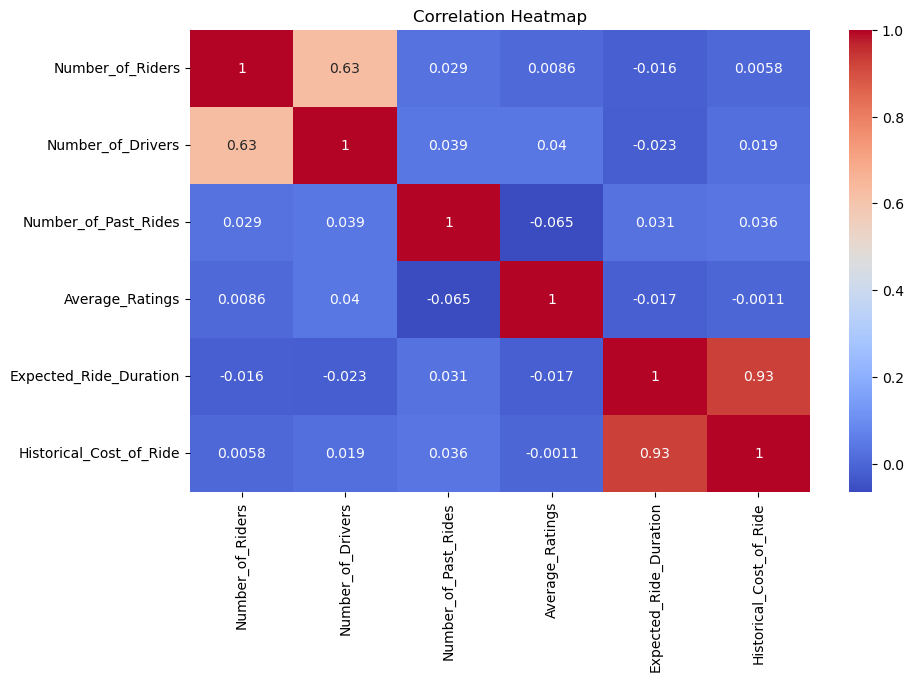

In [23]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [10]:
#define features and target variable
X = df.drop("Historical_Cost_of_Ride", axis=1)
y = df["Historical_Cost_of_Ride"]

In [11]:
#identify categorical and numerical columns
categorical_columns = [
    'Location_Category',
    'Customer_Loyalty_Status',
    'Time_of_Booking',
    'Vehicle_Type'
]

numerical_columns = [
    'Number_of_Riders',
    'Number_of_Drivers',
    'Number_of_Past_Rides',
    'Average_Ratings',
    'Expected_Ride_Duration'
]


In [12]:
#preprocessing
#numerical pipeline
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])


In [13]:
# Categorical Pipeline
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [14]:
# Combine both pipelines
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

In [15]:
#train test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [16]:
#linear regression pipeline

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [17]:
#train model

model.fit(X_train, y_train)

print("\nModel Training Completed")


Model Training Completed


In [19]:
#predictions
y_pred = model.predict(X_test)


In [24]:
#evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("\nModel Evaluation:")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")



Model Evaluation:
Mean Absolute Error: 52.56
Mean Squared Error: 4546.89
R^2 Score: 0.88


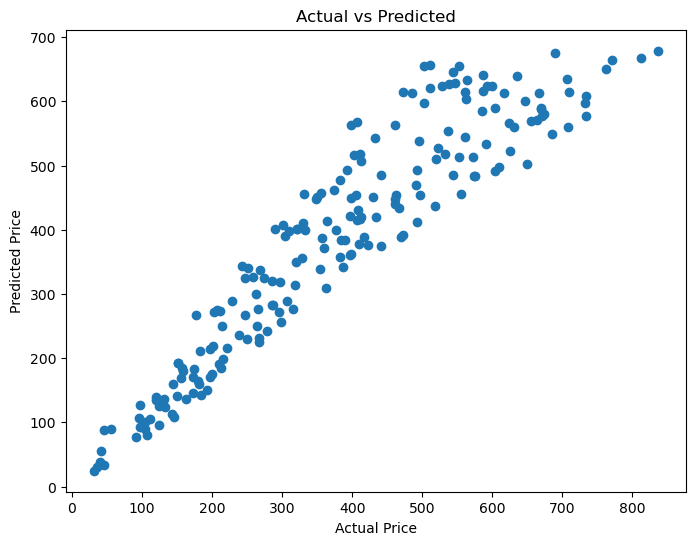

In [25]:
#actual vs predicted
# Plot Actual vs Predicted

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

In [21]:
#save model
joblib.dump(model, "linear_regression_model.pkl")

print("\nModel Saved Successfully")


Model Saved Successfully


In [22]:
#test single prediction
sample_data = pd.DataFrame({
    "Number_of_Riders": [80],
    "Number_of_Drivers": [35],
    "Location_Category": ["Urban"],
    "Customer_Loyalty_Status": ["Silver"],
    "Number_of_Past_Rides": [50],
    "Average_Ratings": [4.5],
    "Time_of_Booking": ["Evening"],
    "Vehicle_Type": ["Premium"],
    "Expected_Ride_Duration": [120]
})

prediction = model.predict(sample_data)

print("\nPredicted Ride Cost:")
print(prediction[0])


Predicted Ride Cost:
467.60814683737834


In [26]:
#feature importance
feature_names = (
    numerical_columns +
    list(model.named_steps["preprocessor"].transformers_[1][1]
         .named_steps["onehot"].get_feature_names_out(categorical_columns))
)
coefficients = model.named_steps["regressor"].coef_
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", key=abs, ascending=False)
print("\nFeature Importance:")
print(feature_importance)



Feature Importance:
                            Feature  Coefficient
15             Vehicle_Type_Economy   -21.362329
16             Vehicle_Type_Premium    21.362329
3                   Average_Ratings     7.306407
4            Expected_Ride_Duration     3.532755
12          Time_of_Booking_Evening    -3.392394
8      Customer_Loyalty_Status_Gold    -2.832730
5           Location_Category_Rural     2.387519
13          Time_of_Booking_Morning     2.204600
10   Customer_Loyalty_Status_Silver     2.135428
11        Time_of_Booking_Afternoon     1.846860
7           Location_Category_Urban    -1.611168
6        Location_Category_Suburban    -0.776350
9   Customer_Loyalty_Status_Regular     0.697301
14            Time_of_Booking_Night    -0.659065
1                 Number_of_Drivers     0.482147
0                  Number_of_Riders    -0.043301
2              Number_of_Past_Rides     0.023684
